In [13]:
# importing the required libraries 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # used to solve iniitial value differential equation problems
from scipy.integrate import trapezoid # trapezoidal integration method for the area under the curve 


In [14]:
# Setup parameters
q = 1.6e-19 #charge of an electron 
h_bar = 1.05e-34
factor = h_bar/(2*q)

Ic = 1e-03 #critical current of the SIS junction (in Amps)
C = 5.7e-14 #capacitance 
Rn = 4 #Normal resistance of the junction (in Ohms) 
Rs = 2 #Shunt resistance added in parallel.
res = (1/Rn + 1/Rs) #Total effective resistance 

In [15]:
# Input current train parameters:
Ibias = 0.85*Ic #This is the base or the starting current value that is less that Ic
Ip    = 0.2*Ic #This is the current boost given i.e., current is increased from 0.9Ic 
N_pulse = 3 # numper of pulses
t_rec = 30e-12 # recovery time between two pulses in seconds 
rect_width = 5e-12 # width of each rectangular pulse (in case it doesn't get cur by event detection) 

In [16]:
# Initial conditions 
phi_initial = np.arcsin(Ibias/Ic) # Initial phase 
dphi_initial = 0
y0 = [phi_initial, dphi_initial] #storing the initial conditions

In [17]:
# Rectangular current pulse generating function 
def rectangular_pulses(Ibias, Ip, t, tstart, width):
    return Ibias + Ip * float(t >= tstart and t <= tstart + width)

In [18]:
# RCSJ Diff Eq function 
def rcsj_diff_eq(t, y, I_of_t, Ic, C, factor, res):
    I = I_of_t(t)
    return [y[1], I/(C*factor) - (Ic/(C*factor))*np.sin(y[0]) - (1/C)*res*y[1]] #we get this expression from the rcsj differential equation


In [19]:
# Event detection function for a 2pi phase jump 
def phase_event_2pi(t, y, phi_ref):
    return y[0] - phi_ref - 2*np.pi

phase_event_2pi.terminal = True # This is used to stop the ODE when the event is found
phase_event_2pi.direction = +1  # The makes sure that the 2pi phase jump is in the right direction (i.e. while the phase is increasing)


In [21]:
t_full    = []
I_full    = []
y_full    = []
t_events  = np.zeros(N_pulse)
t_pointer = 0.0
Phi0         = 2 * np.pi * factor
Ihigh        = Ibias + Ip
tau_slip_est = Phi0 / (res * np.sqrt(Ihigh**2 - Ic**2))
for k in range(N_pulse):
    print(k)
    t_start = t_pointer
    t0      = t_start
    tMaxPulse = t0 + rect_width + 10e-12
    I_pulse = lambda t, t0=t0: rectangular_pulses(Ibias, Ip, t, t0, rect_width)
    phi_ref = y0[0]
    # Step 1: wrap the function to sneak in phi_ref
    # This function is used to determine the required event (i.e. 2pi phase jump) for each pulse
    # since each pulse would have a different event value. 
    # This is automatically handled by the ode45 in MATLAB, but needs to be explicitly defined as a separate
    # function in python.
    def event_fn(t, y, phi_ref=phi_ref):
        return phase_event_2pi(t, y, phi_ref)
    event_fn.terminal  = True
    event_fn.direction = +1
    # Step 2: attach terminal and direction yourself
    event_fn.terminal  = True
    event_fn.direction = +1
    sol1 = solve_ivp(
        fun    = lambda t, y: rcsj_diff_eq(t, y, I_pulse, Ic, C, factor, res),
        t_span = (t_start, tMaxPulse),
        y0     = y0,
        method = 'RK45',
        events = event_fn,
        rtol   = 1e-10,
        atol   = 1e-13,
        max_step = tau_slip_est / 50
    )

    if len(sol1.t_events[0]) == 0:
        raise RuntimeError(f'Pulse {k}: No 2π slip detected.')
    
    te = sol1.t_events[0][0]
    ye = sol1.y_events[0][0]
    t_events[k] = te
    t1 = sol1.t
    y1 = sol1.y.T
    #print(te)
    if len(t_full) > 0:
        t1 = t1[1:]
        y1 = y1[1:]

    t_full = t_full + list(t1)
    y_full = y_full + list(y1)
    I_full = I_full + [I_pulse(t) for t in t1]
    
    # This is the part after event detection,
    #where the pulse is back at I_bias
    # So here we solve the differential equation at a lower current and without the event detection
    I_hold = lambda t, Ibias=Ibias: Ibias
    t2span = (te, te + t_rec)

    sol2 = solve_ivp(
        fun      = lambda t, y, I_pulse=I_pulse: rcsj_diff_eq(t, y, I_pulse, Ic, C, factor, res),
        t_span   = t2span,
        y0       = ye,
        method   = 'RK45',
        rtol     = 1e-10,
        atol     = 1e-13,
        max_step = tau_slip_est / 50
    )

    t2 = sol2.t
    y2 = sol2.y.T

    t2 = t2[1:]
    y2 = y2[1:]

    t_full = t_full + list(t2)
    y_full = y_full + list(y2)
    I_full = I_full + [Ibias] * len(t2)

    t_pointer = t_full[-1]
    y0 = list(y_full[-1])
    

0
1
2


In [22]:
t_full = np.array(t_full)
y_full = np.array(y_full)
I_full = np.array(I_full)

phi  = y_full[:, 0]
dphi = y_full[:, 1]
V    = factor * dphi

# Determining the total area under the curve
area = trapezoid(V, t_full)
print(f"Area under V(t): {area:.4e} V-s,  "
      f"Phi0: {factor*2*np.pi:.4e} V-s,  "
      f"ratio: {area/(factor*2*np.pi):.6f}")

Area under V(t): 6.1851e-15 V-s,  Phi0: 2.0617e-15 V-s,  ratio: 3.000023


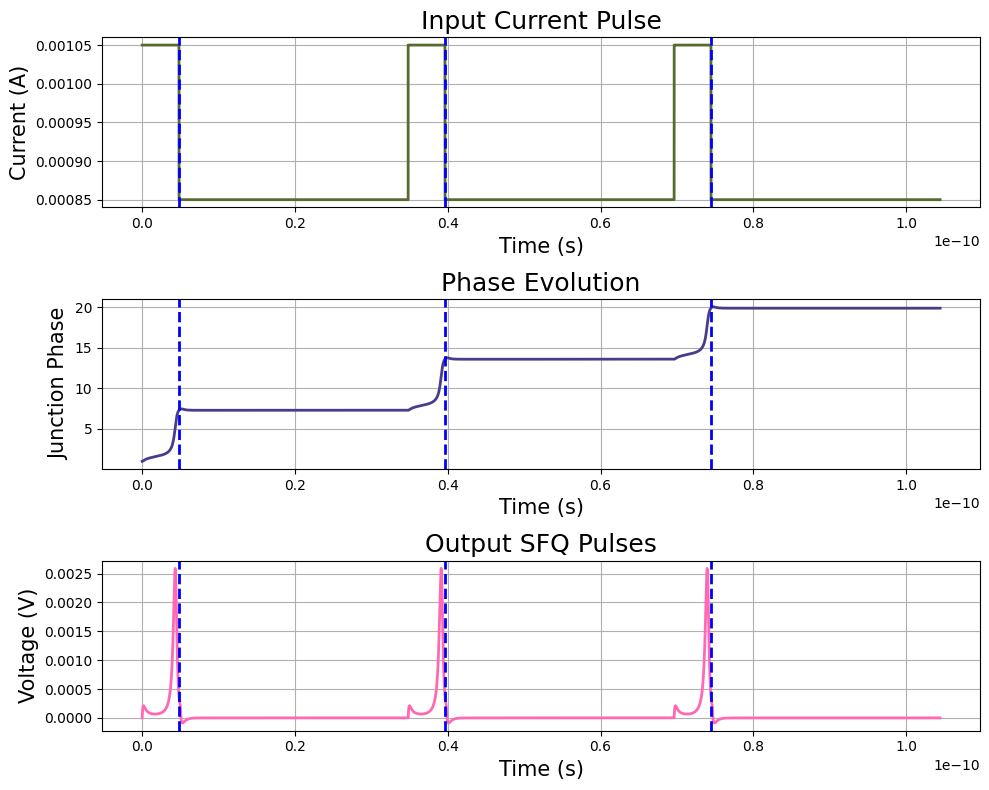

In [23]:
# Plots
%matplotlib inline
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# --- Subplot 1: Current ---
axes[0].plot(t_full, I_full, linewidth=2, color='#556b2f')
for te in t_events:
    axes[0].axvline(x=te, linestyle='--', color='blue', linewidth=2)
axes[0].set_xlabel('Time (s)', fontsize=15)
axes[0].set_ylabel('Current (A)', fontsize=15)
axes[0].set_title('Input Current Pulse', fontsize=18)
axes[0].grid(True)

# --- Subplot 2: Phase ---
axes[1].plot(t_full, phi, linewidth=2, color='#483d8b')
for te in t_events:
    axes[1].axvline(x=te, linestyle='--', color='blue', linewidth=2)
axes[1].set_xlabel('Time (s)', fontsize=15)
axes[1].set_ylabel('Junction Phase', fontsize=15)
axes[1].set_title('Phase Evolution', fontsize=18)
axes[1].grid(True)

# --- Subplot 3: Voltage ---
axes[2].plot(t_full, V, linewidth=2, color='#ff69b4')
for te in t_events:
    axes[2].axvline(x=te, linestyle='--', color='blue', linewidth=2)
axes[2].set_xlabel('Time (s)', fontsize=15)
axes[2].set_ylabel('Voltage (V)', fontsize=15)
axes[2].set_title('Output SFQ Pulses', fontsize=18)
axes[2].grid(True)

plt.tight_layout()
plt.show()